In [1]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [2]:
from diffusers import DDPMScheduler, UNet2DModel
import torch
import os
import random
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from tqdm import tqdm
import torchvision.models as models
import torch.nn as nn
import torch.nn.functional as F

/home/danya/diffusion/.env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
IMG_PATH = './img/img_align_celeba/img_align_celeba'
# IMG_PATH = '/kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba'

In [4]:
max_timesteps = 100

noise_scheduler = DDPMScheduler(num_train_timesteps=max_timesteps,
                                beta_start=0.0001,
                                beta_end=0.1,
                                )

In [5]:
# function to load a random image from ./img/img_align_celeba/img_align_celeba
# and return it as a tensor
def load_random_img():
    img_name = random.choice(os.listdir(IMG_PATH))
    img = Image.open(os.path.join(IMG_PATH, img_name)).convert('RGB')
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])
    return transform(img).unsqueeze(0)

In [24]:
def load_img(img_path):
    img = Image.open(img_path).convert('RGB')
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])
    return transform(img).unsqueeze(0)

In [6]:
def denormalize(image):
    image = image.squeeze(0).permute(1, 2, 0).numpy()
    image = image * 0.5 + 0.5
    return image.clip(0, 1)

In [7]:
def plot_images(timesteps, images):
    img_height, img_width = images[0].shape[:2]
    num_images = len(timesteps)
    num_cols = min(num_images, 10)
    num_rows = (num_images + num_cols - 1) // num_cols
    
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(img_width * num_cols / 100, img_height * num_rows / 100))
    axs = axs.flatten() if num_rows > 1 else [axs]
    
    for i, ax in enumerate(axs):
        if i < num_images:
            ax.imshow(images[i])
            ax.axis('off')
            ax.set_title(f'Timestep {timesteps[i]}')
        else:
            ax.axis('off')
    plt.show()

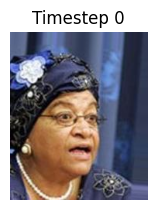

In [8]:
image = load_random_img()
plot_images([0], [denormalize(image)])

In [9]:
img_shape = image.shape
img_shape

torch.Size([1, 3, 218, 178])

In [10]:
timesteps = torch.arange(max_timesteps)
noise = torch.randn(img_shape)

In [11]:
noisy_images = noise_scheduler.add_noise(image, noise, timesteps)

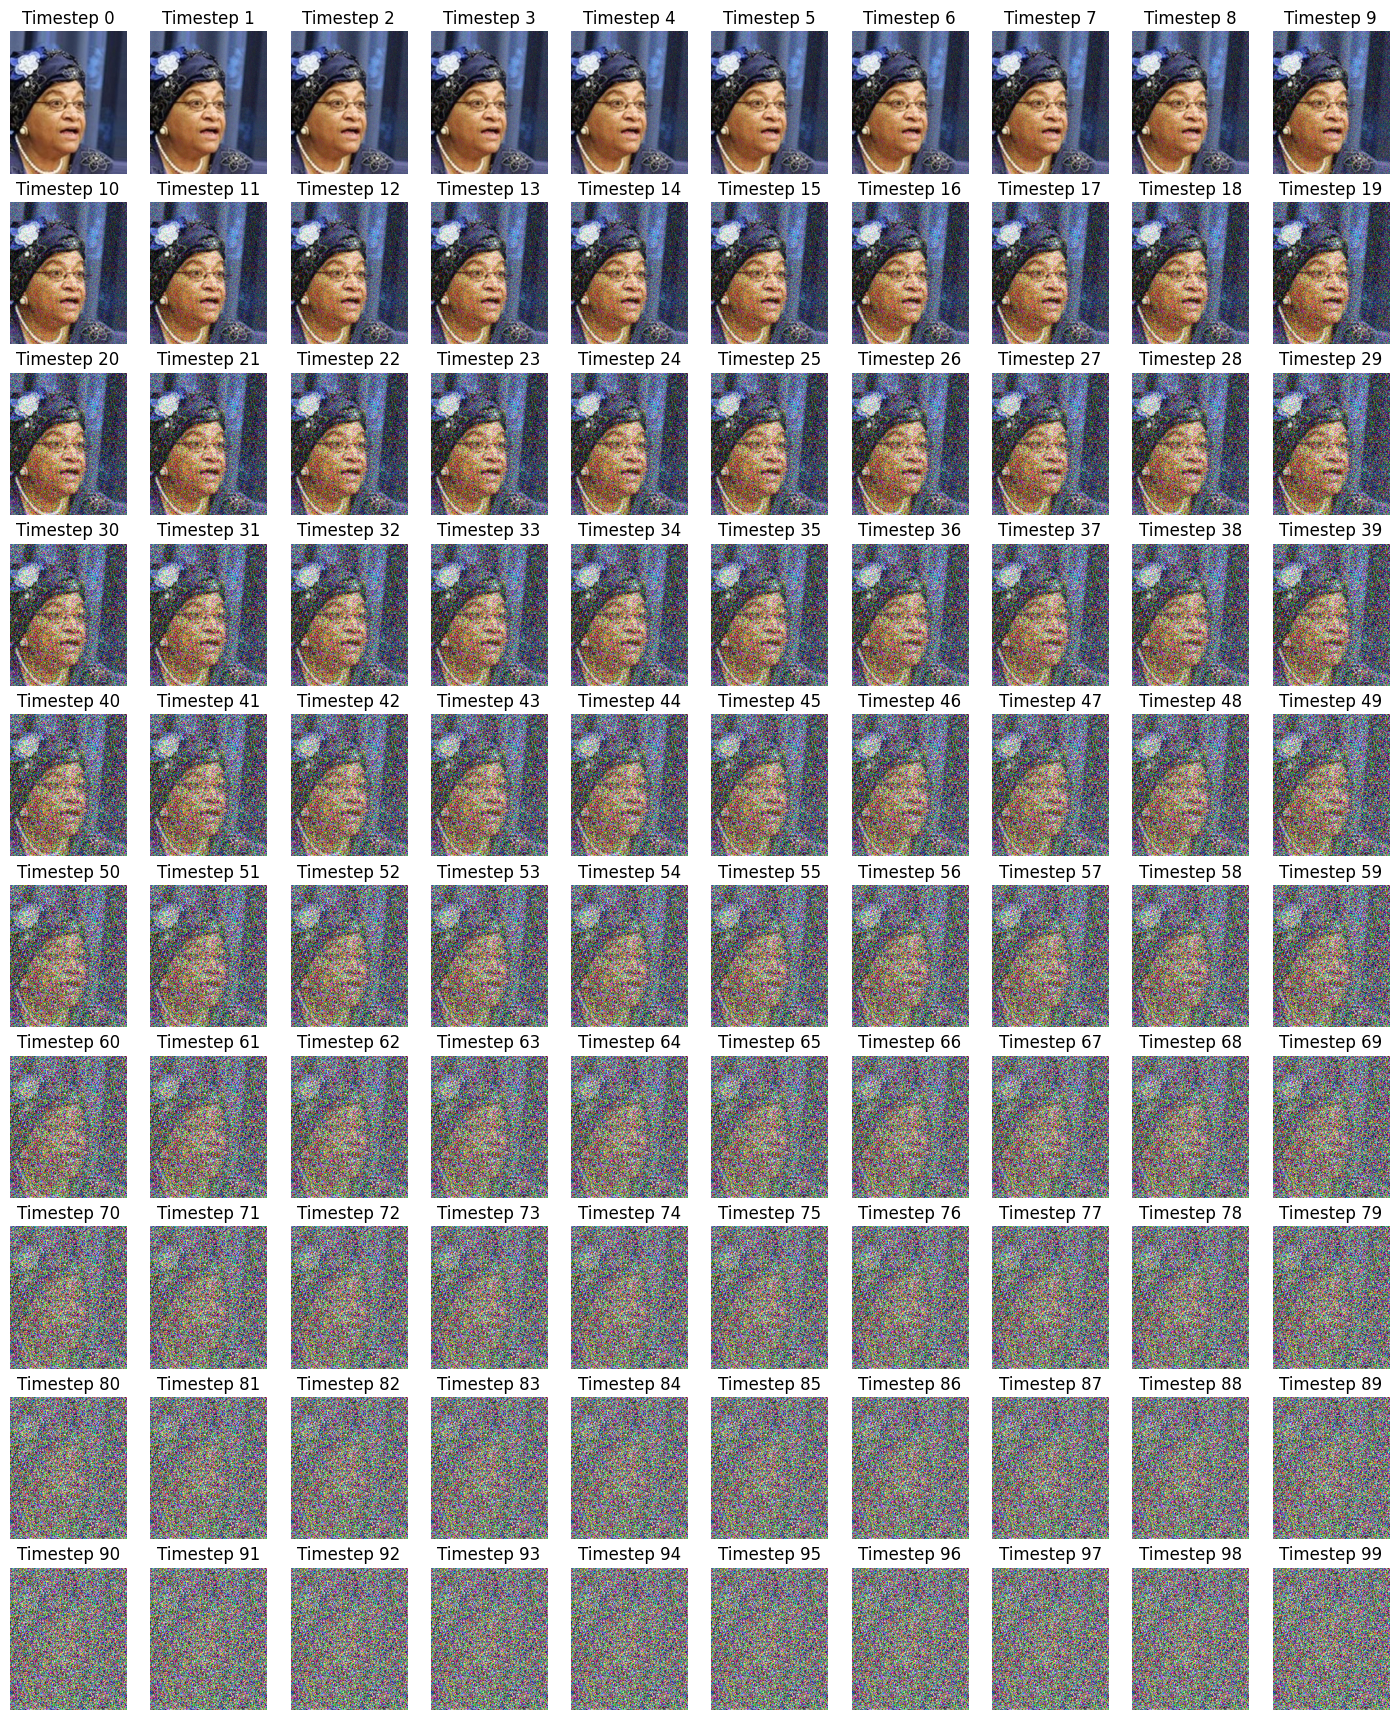

In [12]:
plot_images(timesteps, [denormalize(img) for img in noisy_images])

---

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [29]:
# Transform to [C, H, W] format
transform = transforms.Compose([
    # transforms.ToPILImage(),
    transforms.Resize((128, 128)),
    # transforms.RandomHorizontalFlip(),
    # transforms.RandomRotation(30),
    # transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),  # converts [H, W, C] from PIL to [C, H, W] Tensor
    transforms.Normalize([0.5], [0.5])
])

# Create a dataset
dataset = ImageFolder(
root="./img/img_align_celeba",
    transform=transform
)

# train_size = int(0.9 * len(dataset))
# val_size = int(0.05 * len(dataset))
# test_size = len(dataset) - train_size - val_size
# train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, val_size, test_size])

# # Create dataloaders
# train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

dataloader = DataLoader(dataset, batch_size=256, shuffle=True, num_workers=4)

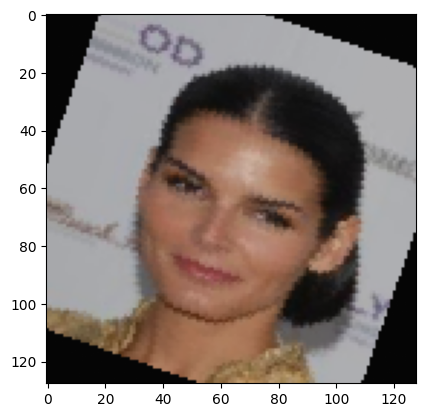

In [15]:
image = next(iter(dataloader))[0][0]
image.shape

plt.imshow(denormalize(image))

In [16]:
class SpatialVAE(torch.nn.Module):
    def __init__(self, latent_channels=3, inside_channels=16):
        super(SpatialVAE, self).__init__()
        self.latent_channels = latent_channels
        
        # Encoder: Downsample from 128x128 to 32x32
        self.encoder = torch.nn.Sequential(
            # Input: (3, 128, 128)
            torch.nn.Conv2d(3, inside_channels, kernel_size=4, stride=2, padding=1),   # -> (32, 64, 64)
            torch.nn.ReLU(inplace=True),
            torch.nn.BatchNorm2d(inside_channels),

            torch.nn.Conv2d(inside_channels, inside_channels * 2, kernel_size=4, stride=2, padding=1),  # -> (64, 32, 32)
            torch.nn.BatchNorm2d(inside_channels * 2),
            torch.nn.ReLU(inplace=True)
        )
        # Two convolutional heads to produce the mean (mu) and log-variance (logvar)
        # Both outputs have shape: (latent_channels, 32, 32)
        self.fc_mu = torch.nn.Conv2d(inside_channels * 2, latent_channels, kernel_size=3, stride=1, padding=1)
        self.fc_logvar = torch.nn.Conv2d(inside_channels * 2, latent_channels, kernel_size=3, stride=1, padding=1)
        
        # Decoder: Upsample from latent (3, 32, 32) back to image (3, 128, 128)
        self.decoder = torch.nn.Sequential(
            # Input: (latent_channels, 32, 32)
            torch.nn.ConvTranspose2d(latent_channels, inside_channels * 2, kernel_size=4, stride=2, padding=1),  # -> (64, 64, 64)
            torch.nn.ReLU(inplace=True),
            torch.nn.BatchNorm2d(inside_channels * 2),

            torch.nn.ConvTranspose2d(inside_channels * 2, inside_channels, kernel_size=4, stride=2, padding=1),               # -> (32, 128, 128)
            torch.nn.ReLU(inplace=True),
            torch.nn.BatchNorm2d(inside_channels),

            torch.nn.Conv2d(inside_channels, 3, kernel_size=3, stride=1, padding=1),                          # -> (3, 128, 128)
            torch.nn.Tanh()  # Ensure output pixel values are in [-1,1]
        )

    def encode(self, x):
        enc = self.encoder(x)
        mu = self.fc_mu(enc)
        logvar = self.fc_logvar(enc)
        return mu, logvar
    
    def decode(self, z):
        return self.decoder(z)
    
    def reparameterize(self, mu, logvar):
        # Compute standard deviation and sample epsilon (element-wise)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        batch_size = x.size(0)
        # Encode input image to feature maps of shape (batch, 128, 32, 32)
        enc = self.encoder(x)
        # Compute per-pixel (and per-channel) mu and logvar: (batch, 3, 32, 32)
        mu = self.fc_mu(enc)
        logvar = self.fc_logvar(enc)
        # Reparameterize: sample z ~ N(mu, exp(logvar))
        z = self.reparameterize(mu, logvar)
        # Decode latent tensor back to image shape: (batch, 3, 128, 128)
        recon = self.decoder(z)
        return recon, mu, logvar

In [19]:
def train_vae(model, loader, num_epochs=10, learning_rate=0.001):
    model = model.to(device)
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = torch.nn.MSELoss()
    
    for epoch in range(num_epochs):
        running_loss = 0.0
        for images, _ in tqdm(loader, total=len(loader)):
            images = images.to(device)
            optimizer.zero_grad()
            recon, mu, logvar = model(images)
            loss = criterion(recon, images)
            # Compute KL divergence between the latent distribution and a standard normal distribution
            kl_div = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
            loss += 0.001 * kl_div
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {running_loss / len(loader)}')
    print('Finished Training')

In [20]:
vae = SpatialVAE(latent_channels=3)

In [19]:
vae = torch.load("vae.pth")

/tmp/ipykernel_454/1894398497.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vae = torch.load("vae.pth")


In [36]:
torch.save(vae, "vae.pth")

In [21]:
train_vae(vae, dataloader, num_epochs=15, learning_rate=0.001)

100%|██████████| 792/792 [03:37<00:00,  3.64it/s]


Epoch 1/15, Loss: 0.030120651150649092


100%|██████████| 792/792 [03:47<00:00,  3.47it/s]


Epoch 2/15, Loss: 0.011729855139768033


100%|██████████| 792/792 [03:57<00:00,  3.34it/s]


...

Epoch 7/15, Loss: 0.008647888030438223


100%|██████████| 792/792 [04:02<00:00,  3.27it/s]


Epoch 8/15, Loss: 0.008515877415769441


 37%|███▋      | 291/792 [01:30<02:35,  3.21it/s]


KeyboardInterrupt: 

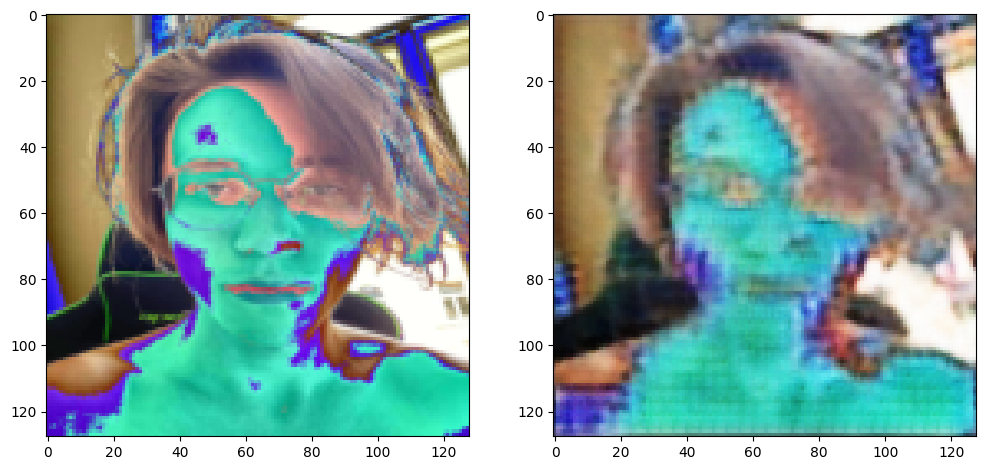

In [ ]:
image = next(iter(dataloader))[0][0].to(device)
# image = transform(transforms.ToPILImage()(load_img("./photo_2025-02-13_16-39-18.jpg")[0])).to(device)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(denormalize(image.cpu()))

plt.subplot(1, 2, 2)

vae.eval()
recon, _, _ = vae(image.unsqueeze(0))
plt.imshow(denormalize(recon.detach().cpu()))

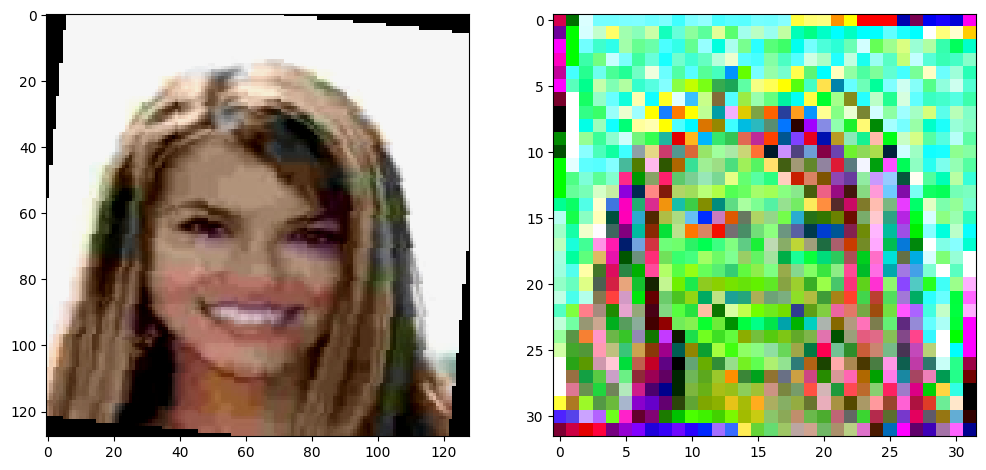

In [23]:
image = next(iter(dataloader))[0][0].to(device)

encoded = vae.reparameterize(*vae.encode(image.unsqueeze(0)))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(denormalize(image.cpu()))

plt.subplot(1, 2, 2)
plt.imshow(denormalize(encoded.detach().cpu()))

In [17]:
# Create a custom augmentation pipeline
augment_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
])

def augment_images(images):
    # images is a batch [B, C, H, W]
    augmented = []
    for img in images:
        pil_img = transforms.ToPILImage()(img)     # Convert to PIL
        pil_aug = augment_transform(pil_img)       # Apply augmentation
        tensor_aug = transforms.ToTensor()(pil_aug)
        normalized_aug = (tensor_aug - 0.5) / 0.5  # Normalize to [-1, 1]
        augmented.append(normalized_aug)
    return torch.stack(augmented, dim=0)  # Return [B, C, 32, 32]

In [34]:
def train_one_epoch(unet, vae, optimizer, loader):
    unet.train()
    losses = []
    for images, _ in tqdm(loader, total=len(loader)):

        # images = augment_images(images).to(device)
        images = vae.reparameterize(*vae.encode(images.to(device))).to(device)

        img_shape = images.shape

        timesteps = torch.randint(0, max_timesteps, (img_shape[0],)).to(device)
        noise = torch.randn(img_shape).to(device)

        noisy_images = noise_scheduler.add_noise(images, noise, timesteps).to(device)

        prediction = unet(noisy_images, timesteps, return_dict=False)[0]

        loss = torch.nn.functional.l1_loss(prediction, noise)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        losses.append(loss.item())

    return losses

In [35]:
model = UNet2DModel(
    sample_size=32,          # Input image size (32x32)
    in_channels=3,           # Input channels (RGB)
    out_channels=3,          # Output channels (RGB)
    layers_per_block=2,      # Keep it simple with 1 layer per block
    block_out_channels=(32, 64, 64, 128),  # Channel progression (lightweight)
    # down_block_types=(
    #     "DownBlock2D",       # Standard downsampling block
    #     "DownBlock2D",
    #     "DownBlock2D",
    #     "AttnDownBlock2D",   # Attention block
    # ),
    # up_block_types=(
    #     "AttnUpBlock2D",     # Attention block
    #     "UpBlock2D",         # Standard upsampling block
    #     "UpBlock2D",
    #     "UpBlock2D",
    # ),
).to(device)

In [36]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

In [38]:
losses = train_one_epoch(model, vae, optimizer, dataloader)

100%|██████████| 792/792 [35:18<00:00,  2.68s/it]


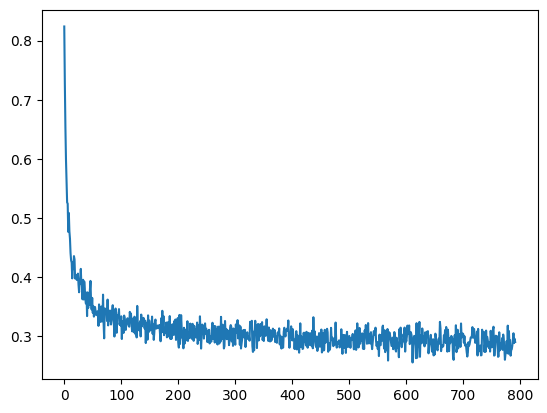

In [39]:
plt.plot(losses)

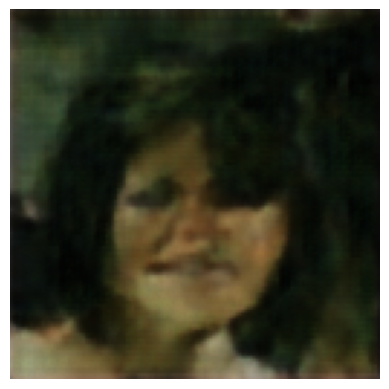

In [42]:
target_img_shape = (3, 32, 32)

generator = torch.Generator(device=device).manual_seed(42)

image = torch.randn((1, *target_img_shape), device=device) #, generator=generator)
timesteps = torch.arange(0, noise_scheduler.timesteps.max(), device=device)

new_images = []

for idx, t in enumerate(reversed(timesteps)):
    with torch.no_grad():
        model_output = model(image, t).sample

    image = noise_scheduler.step(model_output, t, image, generator=generator).prev_sample

plt.imshow(denormalize(vae.decode(image).detach().cpu()))
plt.axis('off')
plt.show()